# Детекция объектов

> inspired by [course](http://wiki.cs.hse.ru/%D0%93%D0%BB%D1%83%D0%B1%D0%B8%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_1_24/25)

### Постановка задачи

 - Данные: изображение и прямоугольники (bounding boxes) ограничивающие положение объектов нескольких классов на изображении
 - Пример датасетов: COCODETECTION, OXFORDIIITPET, PASCAL VOC 2007 и 2012

http://host.robots.ox.ac.uk/pascal/VOC/

![](10.jpg)

### Метрики качества

- Считаем IoU

$$
\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{|A \cap B|}{|A| + |B| - |A \cap B|}
$$

 - Модель выдает для каждого класса список прямоугольников с уверенностями
 - Считаем прямоугольник корректным, если IoU(y, a) = Jaccard(y, a) >= 0.5 (0.75 в новых реализациях)

$$\text{Precision} = \dfrac{TP}{TP + FP}$$  
$$\text{Recall} = \dfrac{TP}{TP + FN}$$


Precision - доля положительных объектов среди всех объектов, которые классификатор назвал положительными.

Recall - доля названных классификатором положительными среди всех объектов, которые являются положительными (найти все объекты на изображении).

Выдаем метки TP, FP, FN:

 - Метка TP выдается в том случае, если IoU > 0.5 и класс определен правильно
 - Метка FP выдается в том случае, если IoU <= 0.5
 - **Метка FN выдается в том случае, если для ground truth боксов выбранного класса не нашлось соответствующего предсказания**

Считаем метрики

 - Строим PR-кривую, затем считаем под ней площадь, получаем Average Precision
 - Усредняем по всем классам, получаем mean Average Precision (mAP)

## Архитектуры нейронных сетей для детекции объектов

### Two-shot detection

Двух-этапное решение задачи:

 1. Найти "кандидатов" - прямоугольники, где скорее всего что-то есть
 2. Классифицировать эти прямоугольники

### R-CNN

https://arxiv.org/abs/1311.2524


 - Для генерации кандидатов используются внешние методы из классического компьютерного зрения
 - Выбирается около 2000 прямоугольников
 - В качестве признаков используются выходы предпоследнего слоя AlexNet (4096)
 - Для классификации SVM one-vs-all

### Fast R-CNN

https://arxiv.org/abs/1504.08083

 - Исправили почти все проблемы R-CNN
 - Всё равно остался отбор кандидатов

### Faster R-CNN

https://arxiv.org/abs/1506.01497


#### Region Proposal Network (RPN)
 - Берем последний тензор из сверточной сети
 - Применяем большой сверточный слой (ядро 3 на 3 и большое количество каналов 512)
 - Для каждой точки берем 9 прямоугольников с разными длинами сторон и соотношениями сторон
 - Для каждого из этих 9 предсказываем есть ли там объект и 4 поправки к сторонам

Сама модель собственно:
 - Всё обучается end-to-end, совместно на сумму из 4 функций потерь
    - Есть ли объект в RPN
    - Регрессия для корректировки размеров прямоугольника в RPN
    - Классификация на K классов в основной модели
    - Регрессия для корректировки прямоугольника в основной модели
 - На этапе применения выделяем самые уверенные в RPN, подаем в основную модель детекции

 - Сохранили такое же качество, но существенно ускорили работу нейронной сети, сделали полностью end-to-end модель

### One-shot detection

### YOLO

https://arxiv.org/abs/1506.02640

![](27.png)
![](29.png)

 - Делим изображение на одинаковые S на S блоков
 - Для каждого блока предсказываем B прямоугольников
 - Каждый прямоугольник - координаты, вероятность наличия объекта, вероятность класса при условии наличия объекта

![](30.png)
![](31.png)

### RetinaNet

https://arxiv.org/abs/1708.02002

## Обучаем модель

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image


In [ ]:
from torchvision.datasets import VOCDetection

dataset = VOCDetection('voc', download=True)

100%|██████████| 2.00G/2.00G [04:41<00:00, 7.10MB/s]


In [ ]:
from torchvision.datasets import VOCDetection

dataset = VOCDetection('voc', image_set='train')

In [ ]:
?? dataset

In [ ]:
len(dataset)

5717

In [ ]:
dataset[0]

(<PIL.Image.Image image mode=RGB size=500x442>,
 {'annotation': {'folder': 'VOC2012',
   'filename': '2008_000008.jpg',
   'source': {'database': 'The VOC2008 Database',
    'annotation': 'PASCAL VOC2008',
    'image': 'flickr'},
   'size': {'width': '500', 'height': '442', 'depth': '3'},
   'segmented': '0',
   'object': [{'name': 'horse',
     'pose': 'Left',
     'truncated': '0',
     'occluded': '1',
     'bndbox': {'xmin': '53', 'ymin': '87', 'xmax': '471', 'ymax': '420'},
     'difficult': '0'},
    {'name': 'person',
     'pose': 'Unspecified',
     'truncated': '1',
     'occluded': '0',
     'bndbox': {'xmin': '158', 'ymin': '44', 'xmax': '289', 'ymax': '167'},
     'difficult': '0'}]}})

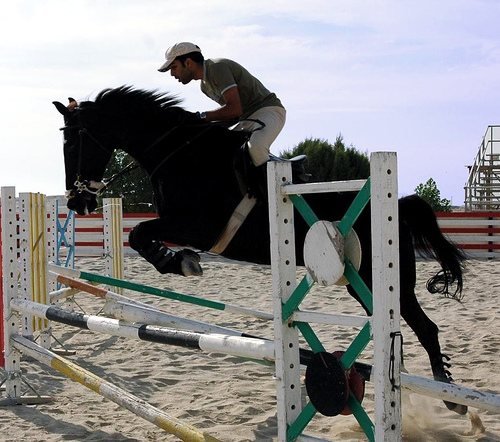

In [ ]:
dataset[0][0]

In [ ]:
target_names = []

for obj in dataset:
    target_names.extend([x['name'] for x in obj[1]['annotation']['object']])

target_names = list(set(target_names))

In [ ]:
target_names

['tvmonitor',
 'train',
 'aeroplane',
 'dog',
 'chair',
 'bus',
 'motorbike',
 'sofa',
 'diningtable',
 'bird',
 'horse',
 'cat',
 'car',
 'bottle',
 'cow',
 'pottedplant',
 'boat',
 'person',
 'bicycle',
 'sheep']

In [ ]:
target2idx = {name: i for i, name in enumerate(target_names)}
idx2target = {i: name for i, name in enumerate(target_names)}

target2idx, idx2target

({'tvmonitor': 0,
  'train': 1,
  'aeroplane': 2,
  'dog': 3,
  'chair': 4,
  'bus': 5,
  'motorbike': 6,
  'sofa': 7,
  'diningtable': 8,
  'bird': 9,
  'horse': 10,
  'cat': 11,
  'car': 12,
  'bottle': 13,
  'cow': 14,
  'pottedplant': 15,
  'boat': 16,
  'person': 17,
  'bicycle': 18,
  'sheep': 19},
 {0: 'tvmonitor',
  1: 'train',
  2: 'aeroplane',
  3: 'dog',
  4: 'chair',
  5: 'bus',
  6: 'motorbike',
  7: 'sofa',
  8: 'diningtable',
  9: 'bird',
  10: 'horse',
  11: 'cat',
  12: 'car',
  13: 'bottle',
  14: 'cow',
  15: 'pottedplant',
  16: 'boat',
  17: 'person',
  18: 'bicycle',
  19: 'sheep'})

In [ ]:
def target_transform(voc_target):
    target = {}

    target['boxes'] = torch.tensor(
        [
            [
                float(x['bndbox']['xmin']),
                float(x['bndbox']['ymin']),
                float(x['bndbox']['xmax']),
                float(x['bndbox']['ymax'])
            ] for x in voc_target['annotation']['object']
        ],
        dtype=torch.float32
    )
    target['labels'] = torch.tensor([target2idx[x['name']] for x in voc_target['annotation']['object']], dtype=torch.int64)

    return target

In [ ]:
target_transform(dataset[0][1])

{'boxes': tensor([[ 53.,  87., 471., 420.],
         [158.,  44., 289., 167.]]),
 'labels': tensor([10, 17])}

In [ ]:
from torchvision.utils import draw_bounding_boxes


def show(imgs):
    to_pil = T.ToPILImage()

    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(8, 4))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = to_pil(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

def draw_boxes_single_image(image, boxes, labels):
    colors = ["red" for _ in boxes]

    show(draw_bounding_boxes(image, boxes, labels, colors=colors, width=5))

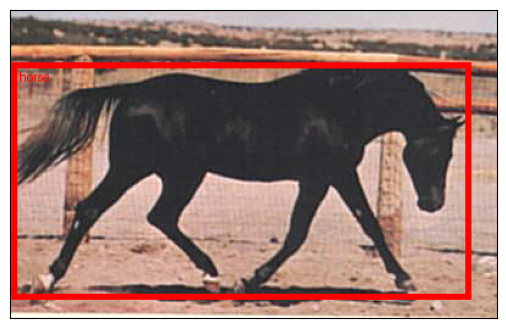

In [ ]:
import torchvision.transforms as T

index = 105
draw_boxes_single_image(
    T.PILToTensor()(dataset[index][0]),
    target_transform(dataset[index][1])['boxes'],
    [idx2target[label.item()] for label in target_transform(dataset[index][1])['labels']]
)

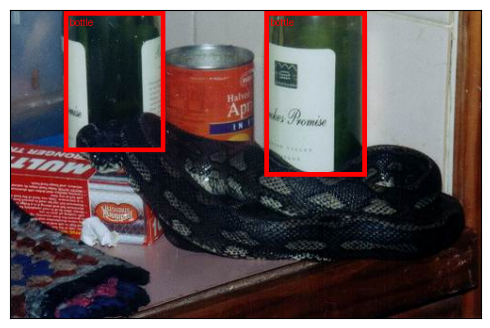

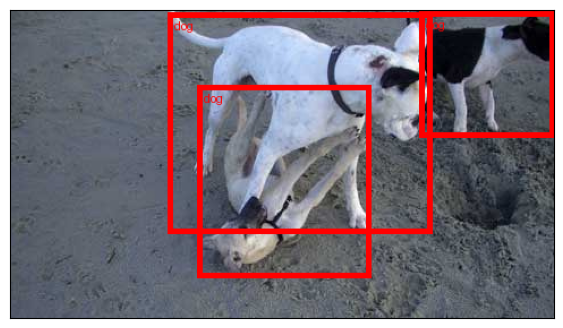

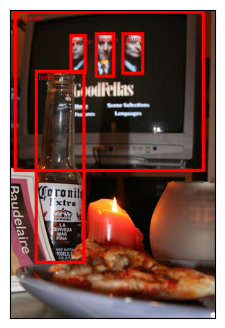

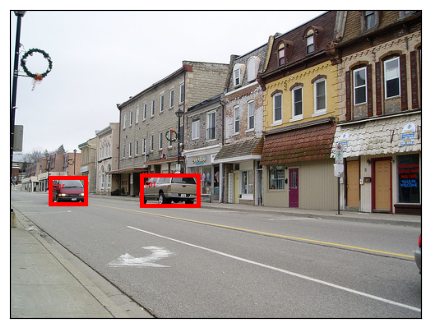

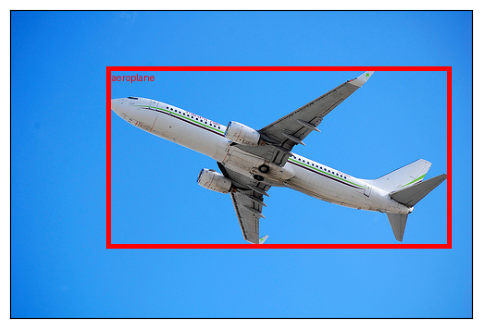

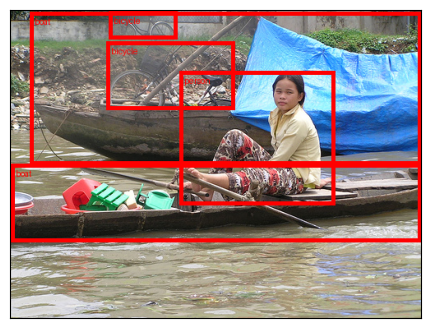

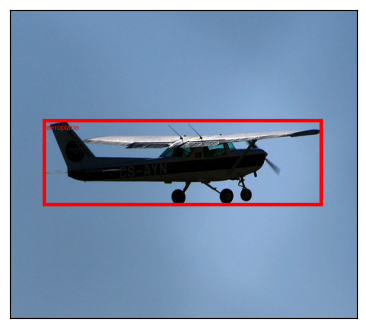

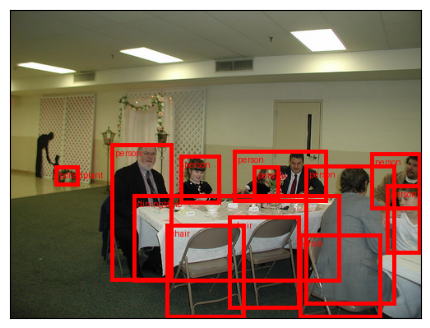

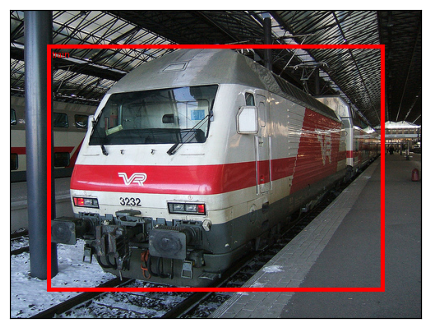

In [ ]:
for i in range(1, 10):
    draw_boxes_single_image(
        T.PILToTensor()(dataset[i][0]),
        target_transform(dataset[i][1])['boxes'],
        [idx2target[label.item()] for label in target_transform(dataset[i][1])['labels']]
    )

In [ ]:
from torch.utils.data import DataLoader


def collate_fn(batch):
    return tuple(zip(*batch)) #for x, y in batch

dataset_train = VOCDetection(
    'voc',
    image_set='train',
    transform=T.ToTensor(),
    target_transform=target_transform
)

dataset_test = VOCDetection(
    'voc',
    image_set='val',
    transform=T.ToTensor(),
    target_transform=target_transform
)

train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True, num_workers=8, pin_memory=True, collate_fn=collate_fn)
valid_loader = DataLoader(dataset_test, batch_size=8, shuffle=False, num_workers=8, pin_memory=True, collate_fn=collate_fn)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_320_fpn, FasterRCNN_MobileNet_V3_Large_320_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


def get_detection_model():
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.COCO_V1)  # COCO

    model.roi_heads.box_predictor = FastRCNNPredictor(1024, len(target_names))

    return model

In [ ]:
model = get_detection_model()

model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

In [ ]:
# !pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.7 MB/s eta 0:00:00


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import batched_nms


def intersection_over_union(dt_bbox, gt_bbox):
    int_x0 = max(dt_bbox[0], gt_bbox[0])
    int_y0 = max(dt_bbox[1], gt_bbox[1])

    int_x1 = min(dt_bbox[2], gt_bbox[2])
    int_y1 = min(dt_bbox[3], gt_bbox[3])

    intersection = max(int_x1 - int_x0, 0) * max(int_y1 - int_y0, 0)
    dt_area = (dt_bbox[2] - dt_bbox[0]) * (dt_bbox[3] - dt_bbox[1])
    gt_area = (gt_bbox[2] - gt_bbox[0]) * (gt_bbox[3] - gt_bbox[1])

    return intersection / (dt_area + gt_area - intersection)


def apply_nms(orig_prediction, iou_thresh=0.3):

    keep = batched_nms(orig_prediction['boxes'], orig_prediction['scores'], orig_prediction['labels'], iou_thresh)

    final_prediction = orig_prediction

    final_prediction['boxes'] = final_prediction['boxes'][keep]
    final_prediction['scores'] = final_prediction['scores'][keep]
    final_prediction['labels'] = final_prediction['labels'][keep]

    return final_prediction


@torch.inference_mode()
def visualize(model, batch):
    model.eval()

    to_pil = T.ToPILImage()
    to_tensor = T.PILToTensor()

    xs, ys = batch

    for i, (x, y) in enumerate(zip(xs, ys)):
        prediction = {k: v.to(device) for k, v in model([x.to(device)])[0].items()}

        prediction = apply_nms(prediction)

        x = to_tensor(to_pil(x.cpu()))

        true_boxes = draw_bounding_boxes(x, boxes=y['boxes'], labels=[idx2target[label.item()] for label in y['labels']], width=5, colors='red')
        predicted_boxes = draw_bounding_boxes(x, boxes=prediction['boxes'], labels=[idx2target[label.item()] for label in prediction['labels']], width=5, colors='red')

        fig, ax = plt.subplots(1, 2, figsize=(10, 5), facecolor='white')

        ax[0].imshow(to_pil(true_boxes))
        ax[1].imshow(to_pil(predicted_boxes))

        ax[0].axis('off')
        ax[1].axis('off')

        ax[0].set_title('Target boxes')
        ax[1].set_title('Predicted boxes')

        plt.subplots_adjust(wspace=0, hspace=0.1)
        plt.show()

        if i >= 9:
            break

In [ ]:
device = 'cuda'

In [ ]:
from torch.optim import Adam
from tqdm.notebook import tqdm

def train(model):
    model.train()

    metric = MeanAveragePrecision()

    for x, y in tqdm(train_loader, desc='Train'):

        x = list(im.to(device).float() for im in x)
        y = [{k: v.to(device) for k, v in t.items()} for t in y]

        optimizer.zero_grad()

        output = model(x, y)

        loss_sum = sum(loss for loss in output.values())

        loss_sum.backward()

        optimizer.step()

In [ ]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    metric = MeanAveragePrecision()

    for x, y in tqdm(loader, desc='Evaluation'):
        x = list(im.to(device).float() for im in x)

        output = model(x)

        output = [{k: v.cpu() for k, v in t.items()} for t in output]

        metric.update(output, y)

    return metric.compute()['map']

In [ ]:
from IPython.display import clear_output


def whole_train_valid_cycle(model, num_epochs, title):
    batch = next(iter(valid_loader))

    for epoch in range(num_epochs):
        train(model)


        clear_output()

        visualize(model, batch)
        print("Valid mAP: ", evaluate(model, batch))

In [ ]:
model = get_detection_model().to(device)

optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

In [ ]:
whole_train_valid_cycle(model, 15, 'Faster R-CNN finetune')

In [ ]:
train_map = evaluate(model, train_loader)
valid_map = evaluate(model, valid_loader)

print(f'Train mAP {train_map:.5f} Valid mAP {valid_map:.5f}')

## Обучение YOLO (10 баллов)

### Задание 1 (3 балла)

1. Заходим на https://universe.roboflow.com/ и создаем аккаунт
2. Генерируем api-ключ для скачивания датасета
3. Скачиваем датасет mushrooms-yolov5 из воркспейса denis-7enby
4. Обучаем YOLO11n на 3-5 эпохах


In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key='your key here')

project = rf.workspace("denis-7enby").project("mushrooms-yolov5")
dataset = project.version(1).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mushrooms-yolov5-1 in yolov11:: 100%|██████████| 16872/16872 [00:01<00:00, 8830.33it/s] 


In [ ]:
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics import YOLO
import torch


model = YOLO("yolo11n.pt")
# your code here
preds = ...


In [ ]:
# watch results

def plot_yolo_preds(preds):      
    img = preds[0].plot()
    img_rgb = img[:, :, ::-1]

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

plot_yolo_preds(preds)

In [12]:
# training example

model.train(
    data="path to dataset",
    epochs=3,
    imgsz=640,
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mushrooms-yolov5-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

KeyboardInterrupt: 

In [ ]:
# your code here
preds = ...

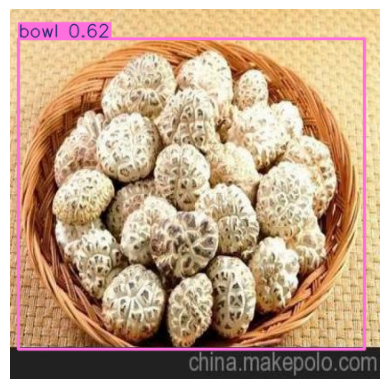

In [ ]:
plot_yolo_preds(preds)

### Задание 2 (до 7 баллов)


| Балл | mAP@0.5 | Что требуется дополнительно               |
| ---- | ------- | ----------------------------------------- |
| 1    | > 0.30  | Модель обучена, базовый запуск            |
| 2    | > 0.50  | Подбор гиперпараметров, аугментации       |
| 3    | > 0.65  | Работа с дисбалансом классов, fine-tuning |
| 4    | > 0.75  | Анализ ошибок, разбор сложных классов     |  


> - Дополнительные баллы (до 3) можно получить за топ 1-3 на лидерборде  
> - **NOTE! При большом количестве высоких скоров, баллы будут пересмотрены с учетом положения на лидербоде**
> - Чтобы задание было засчитано, необходимо так же сдать графики c логами метрик (допускается приложить tensorboard или ссылку на W&B).  
> Успехов

In [ ]:
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics import YOLO
import torch

class StudentTrainer(DetectionTrainer):

    """
    Feel free to implement your own approach (you can follow the suggestions above or not).
    Good luck!

    NOTE: it is advisable to add LR warmup to stabilize training and improve convergence
    """

    def get_model(self, cfg=None, weights=None, verbose=True):
        """Freeze the backbone (layers 0–9) after loading weights."""
        model = super().get_model(cfg, weights, verbose)
        # your code here
        return model

    def optimizer_step(self):
        """Add gradient clipping before the optimizer step."""
        # your code here
        pass

    def on_train_epoch_end(self):
        """Log box/cls/dfl losses to a list for later plotting"""
        super().on_train_epoch_end()
        # your code here

    def on_train_batch_end(self):
        """Print a custom progress line every 20 batches."""
        super().on_train_batch_end()
        # your code here



model = YOLO("yolo11n.pt")


model.train(
    data="path to your dataset",
    epochs=..., # your code here
    imgsz=640,
    batch=..., # your code here
    device=..., # your code here
    trainer=StudentTrainer,
)
